In [1]:
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
from cooling import get_t_cool_n, get_t_cool_cgs, load_cooling_table, get_t_cool_min, get_c_s, initialize_cooling_constants
import astropy.units as u
import astropy.constants as C
from flow_props import vel_evolution, mass_evolution
from stratified_box import StratifiedBox
import os
import latexify
from tqdm.notebook import tqdm
import itertools


# Unit conversions
pc   = 3.086e18
Myr  = 3.15576e13
Msun = 1.989e33
km   = 1e5
mbar = 9.8e-25
H = 4

# Load cooling table
load_cooling_table("/viper/ptmp/ferhi/cooling_tables/gnat-sternberg.cooling_1Z")
initialize_cooling_constants(5/3, mbar)

def strat_n(r):
    n0 = 100
    a = 0.001

    return n0 * np.exp(-a * ((1 + (r/a/H)**2)**0.5 -1))

def strat_g(r):
    g0 = 1e-8
    a = 0.001
    return g0 * r/a/H /(1 + (r/a/H)**2)**0.5 

def strat_T(r):
    return np.ones_like(r) * 1e6


In [2]:

class TurbFallingCloud(object):
    """
    Units:
    times       --> Myr
    r_cl        --> pc
    distances   --> kpc
    n           --> cm^-3
    g           --> m/s^2
    velocities  --> km/s
    masses      --> kg
    Integration all done in SI!

    """
    def __init__(self, d0, r_cl0, T_cl = 1e4, vturb = 15, profile = 'MW', tcool = None, v0 = 0, cooling_factor = 1):
        self.d0 = d0 #kpc
        self.r_cl0 = r_cl0 #pc
        self.T_cl = T_cl
        self.vturb = vturb * 1e3
        self.v0 = v0 * 1e3
        if profile == 'MW':
            self.profile_n = strat_n     # cm^-3
            self.profile_g = strat_g     # (same units used elsewhere)
            self.profile_T = strat_T      # K
            
        self.mass0 = 4/3. * (r_cl0 * u.parsec.to('cm') )**3 * np.pi * self.chi(d0) * self.profile_n(d0) * mbar / u.M_sun.to('g')
        if tcool == None:  
            self.Lambda_units = 1
            self.tcool0 = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0)) / u.Myr.to('s')
        else:
            self.Lambda_units = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0)) / u.Myr.to('s') / tcool
            self.tcool0 = tcool
        print("This is Tcool0:", self.tcool0)
        Lturb = r_cl0
        f_A = 0.23
        if self.vturb / 1000 > 30: f_A *= 3.3
        self.tgrow0 = cooling_factor* 12 * (f_A / 0.23)  * (self.chi(d0)/100.) * (self.r_cl0 / 100.) *\
            (Lturb / 100.)**(-0.25) * (self.tcool0 / 0.03 )**(0.25)
        #assert self.tcool0 < (r_cl0 / vturb), f"tgrow0 has to be smaller than tcc: {r_cl0 / vturb} Myr!"
        print("This is gtgrow0:", self.tgrow0 * u.Myr.to('s') * self.profile_g(d0) / 1e2 /1e3)


    def chi(self, d):
        return self.profile_T(d) / self.T_cl

    def rcl(self, d, rfirst = None):
        if rfirst == None: return self.r_cl0* (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        else: return rfirst* (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        

    def profile_P(self, d):
        return self.profile_T(d) * self.profile_n(d)


    def integrate(self,stop_value, f_KH = 1, alpha = 5/6., f_T = 1, verbose = 1, stop_mode = 'time', drag_bool = True):
        """
        Parameters:
            stop_value  -- Depends on `stop_mode` what it can be
            stop_mode   -- Can be:
                             'time' for stopping time in Myr
                             'height' for falling until height (in kpc) above disk
                             'tgrow_over_tcc' for falling until this value is rached
            f_KH        -- 1 for stratified and 5 for constant background recommended
            alpha       -- how does area change with mass change
        """
        def _odefun(t, y):
            # separate variables        
            z, v, m = y
            v = min(0,v)
            z_kpc = z / u.kpc.to('m') 
            rho_h = self.profile_n(z_kpc) * mbar * u.g.to('kg') / (u.cm.to('m')**3)
            g = -self.profile_g(z_kpc) * 1e-2  
            C0 = 0.6 # drag coefficient
            rcl = self.rcl(z_kpc) 
            rcl_m = rcl * u.parsec.to('m')
            Across = np.pi * rcl_m**2 


            r_pc_to_kpc = u.parsec.to('kpc')
            w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
              (self.r_cl0 * r_pc_to_kpc) / \
              abs(self.d0 - z_kpc)


            tcool_cl = get_t_cool_n(self.T_cl, self.profile_n(z_kpc) * self.chi(z_kpc)) / u.Myr.to('s') / self.Lambda_units
            v_tot = self.vturb + (2/(1 + w_KH**2)) * v
            vrat = 150. / min(abs(v_tot)/1000, 150.)

            tcoolrat = tcool_cl / self.tcool0
            mrat = m  / (self.mass0 * u.Msun.to('kg'))
            rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

            tgrow =  self.tgrow0 * u.Myr.to('s') * vrat**(3/5.)* tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha) * (mrat**(1/3.))**0.75
            

            


            def drag(self, rho_h, v, m):
                turb_drag = 0.5 * rho_h * Across * (2* self.vturb**2 + v**2) * C0
                expr = g +turb_drag / m
                return expr
        
            vterm = drag(self = self, rho_h=rho_h, v= v, m=m) - v / tgrow 
            

            dzdt = min(0,v)
            dvdt = min(0,vterm) if v >= 0 else vterm
            dmdt = m / tgrow
            r = [dzdt, dvdt, dmdt]

            return np.array(r) 
        
        y0 = (self.d0 * u.kpc.to('m'), self.v0, self.mass0 * u.M_sun.to('kg'))

        tol = (1e-5 * u.kpc.to('m'), 1e-5 * 1e-5, 1e-5 * self.mass0* u.M_sun.to('kg'))
        o = dict(first_step = 1e-5 * u.Myr.to('s'), atol = tol, max_step = 1 * u.Myr.to('s'))
        if stop_mode == 'tgrow_over_tcc': # integrate until value of t_grow / t_cc is reached
            def _odestop(t, y): 
                return self.tgrow_over_tcc(y[0] / u.kpc.to('m')) + stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'time':
            tend = stop_value * u.Myr.to('s')
        elif stop_mode == 'mass':
            def _odestop(t, y): 
                return y[2] / (self.mass0 * u.Msun.to('kg')) - stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'height':
            def _odestop(t, y): 
                return y[0] / u.kpc.to('m') - stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'tgrow':
            def _odestop(t, y): 
                return stop_value * self.vTgrow(y[0], y[1], y[2]) *1e2 / self.profile_g(y[0] / u.kpc.to('m'))
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        else:
            raise ValueError("Unknown `stop_mode`")
        r = scipy.integrate.solve_ivp(_odefun, (0,tend),y0, **o, dense_output=True)
        if verbose > 0:
            print(r['message'])

        self.integration_result = r
        return r
    
    def vTgrow(self, z,v,m, alpha=5/6, f_T = 1.):
        z_kpc = z / u.kpc.to('m')
        w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *
            (self.r_cl0 * u.pc.to('kpc')) /
            (self.d0 - z_kpc))


        tcool_cl = get_t_cool_n(self.T_cl, self.profile_n(z_kpc) * self.chi(z_kpc)) / u.Myr.to('s') / self.Lambda_units
        vrat = np.ones_like(z_kpc)
        v_turb  = abs(self.vturb)/1000.
        v_infall = abs(v)/1000.


        v_tot = v_turb + (2/(1 + w_KH**2)) * v_infall
        vrat = 150. / np.minimum(abs(v_tot), 150.)

        # Result array:
        #vrat = np.where(
        #    w_KH > 1,
        #    150. / v_turb,
        #    150. / v_infall
        #)
        tcoolrat = tcool_cl / self.tcool0
        mrat = m  / (self.mass0 * u.Msun.to('kg'))
        rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

        tgrow = self.tgrow0 * u.Myr.to('s') * vrat**(3/5.) * tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)* (mrat**(1/3.))**0.75
        return self.profile_g(z_kpc) * tgrow / 1e2
    
    def vTdrag(self, z,m):
        z_kpc = z / u.kpc.to('m')
        rcl = self.rcl(z_kpc) * u.pc.to('m')  # Also fix: use z_kpc
        rho_h = self.profile_n(z_kpc) * mbar * u.g.to('kg') / (u.cm.to('m')**3)  # Convert to kg/m³
        #return np.sqrt(2 * m * self.profile_g(z_kpc) * 1e-2 / (rho_h * np.pi * rcl**2 * 0.6)) - self.vturb / np.sqrt(0.6)
        return np.maximum(np.ones_like(z) * np.sqrt(2 * m * self.profile_g(z_kpc) * 1e-2 / (rho_h * np.pi * (self.r_cl0 * u.pc.to('m'))**2 * 0.6)) -  self.vturb, 0)

        #return np.ones_like(z) * rho_h * self.vturb**2 * np.pi * self.r_cl0**2 

    def plot_trajectory(self):
        assert self.integration_result is not None, "Have to run integrate first."
        r = self.integration_result
        Myr = u.Myr.to('s')


        plt.plot(r['t'] / Myr, r['y'][0] / u.kpc.to('m'),'-')
        plt.xlabel("t")
        plt.ylabel("z")
        plt.figure()
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.plot(r['t'] / Myr, self.vTgrow(r['y'][0], r['y'][1], r['y'][2])/1e3, color='red')
        plt.plot(r['t'] / Myr, self.vTdrag(r['y'][0],  r['y'][2])/1e3, color='black')
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        #plt.yscale('log')
        plt.ylim(-10,100)
        plt.xlabel("t")
        plt.ylabel("v")
        plt.figure()
        plt.plot(r['t'] / Myr, r['y'][2] / r['y'][2][0])
        plt.xlabel("t")
        plt.yscale('log')
        plt.ylabel("Mass (Msun)")


    def plot_timescales(self):
        r = self.integration_result
        time = r['t'][::-1] / u.Myr.to('s')
        plt.plot(time, self.vTgrow(r['y'][0], r['y'][1], r['y'][2]))
        plt.axhline(4, c='black', alpha = 0.5)
        plt.xlabel("t (Myr)")
        plt.ylabel("tgrow / tcc")


class CompareRuns(object):

    def __init__(self, r_cl0, rundir, T_cl = 1e4, vturb = 15, profile = 'MW', tcool = None, v0 = 0., cooling_factor = 1):

        self.rundir = rundir
        self.sim = StratifiedBox(os.path.join(self.rundir, 'strat.in'), dir=self.rundir)
        self.cloud = TurbFallingCloud(self.sim.y_centre/1e3, r_cl0, T_cl, vturb=vturb, profile=profile, tcool=tcool, v0 = v0, cooling_factor = cooling_factor)
        self.rundir = rundir
                # Load simulation


    def compare_plots(self, item, stop_mode='time', drag_bool = True):
        
        r = self.cloud.integrate(item, stop_mode=stop_mode, drag_bool=drag_bool)


        times, norm_mass, cgout, wgout, total = mass_evolution(self.rundir, gout=True)
        tvs, vel = vel_evolution(self.rundir)
        mask = ~np.isnan(norm_mass)
        timeseries = times/self.sim.t_eddy - 6
        idx_0 = np.argmin(np.abs(timeseries))
        norm_mass = norm_mass- norm_mass[idx_0]

        timeseries = timeseries[mask] * self.sim.t_eddy * self.sim.code_time_cgs / u.Myr.to('s')
        norm_mass = 10**norm_mass[mask]

        # Plot with integrated results
        plt.style.use('custom_plot')
        Myr = u.Myr.to('s')
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.ylim(-10,100)
        plt.plot(r['t'] / Myr, self.cloud.vTgrow(r['y'][0], r['y'][1], r['y'][2])/1e3, color='red')
        plt.plot(r['t'] / Myr, self.cloud.vTdrag(r['y'][0],  r['y'][2])/1e3, color='black')
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        plt.plot(timeseries, vel * self.sim.code_length_cgs / self.sim.code_time_cgs / 1e5, alpha = 0.8, label='sim')
        #plt.yscale('log')
        plt.xlabel("t")
        plt.ylabel("v")
        plt.figure()
        plt.plot(r['t'] / Myr, r['y'][2] / r['y'][2][0])
        plt.scatter(timeseries, norm_mass, alpha=0.8, label='sim', color='orange')
        plt.xlabel("t")
        plt.yscale('log')
        plt.ylabel("m / m0")

In [3]:
def get_v_at_m3m0(r0,h,vturb):
        
    # Run model
    cloud = TurbFallingCloud(h,r0, vturb=vturb)
    

    sol = cloud.integrate(1e3, stop_mode='mass')

    if len(sol.t_events[0]) > 0:
        t_end = sol.t_events[0][0]
    else:
        t_end = sol.t[-1]

    # Convert to a continuous solution
    t_range = np.linspace(0, t_end, 1000)
    solution = sol.sol(t_range)


    # compute L
    z = solution[0]
    v = -solution[1]
    m = solution[2]

    idx_vmax = np.argmax(v)

    tgrow = cloud.tgrow0
    return (v[idx_vmax], tgrow) if (v[idx_vmax] > 0) else (0, tgrow)

In [4]:
def get_tgrow_over_tcc_at_vmax(r0,h,vturb):
        
    # Run model
    cloud = TurbFallingCloud(h,r0, vturb=vturb)

    def in_safe_zone(h):
        pressure =  cloud.profile_n(h) * cloud.profile_T(h)
        safe_pressure = 3000*(cloud.profile_g(h)/(1e-8))**0.8 * ((cloud.profile_T(h)/1e6))**(12/5)
        return (pressure > safe_pressure)
    

    sol = cloud.integrate(0.01, stop_mode='height')

    if len(sol.t_events[0]) > 0:
        t_end = sol.t_events[0][0]
    else:
        t_end = sol.t[-1]

    # Convert to a continuous solution
    t_range = np.linspace(0, t_end, 1000)
    solution = sol.sol(t_range)


    # compute L
    z = solution[0]
    v = -solution[1]
    m = solution[2]

    idx_vmax = np.argmax(v)

    if in_safe_zone(h):
        return 0, v[idx_vmax]
    
    
    tgrow_vmax = cloud.vTgrow(z[idx_vmax], v[idx_vmax], m[idx_vmax]) * 1e2 / cloud.profile_g(z[idx_vmax])
    tcc_vmax = np.sqrt(cloud.profile_T(z[idx_vmax])/1e4)*r0 * u.pc.to('m')/v[idx_vmax]

    return tgrow_vmax/tcc_vmax, v[idx_vmax]

In [5]:
from tqdm.notebook import tqdm
import itertools

rcllst10 = np.logspace(-5,3,30)
d0lst10  = np.logspace(-1,2,30) #10,10)

combs = list(itertools.product(rcllst10,d0lst10))
vlst10 = []
fclst10 = []
tgrow_10 = []
for rcl, d0 in tqdm(combs):
    tt, tgrow = get_v_at_m3m0(rcl,d0, vturb=10)
    trat = get_tgrow_over_tcc_at_vmax(rcl, d0, vturb=10)
    vlst10.append(tt/1e3)
    fclst10.append(trat[0])
    tgrow_10.append(tgrow)

  0%|          | 0/900 [00:00<?, ?it/s]

This is Tcool0: 1.2025477349244795e-07
This is gtgrow0: 9.521016607079487e-06
A termination event occurred.
This is Tcool0: 1.2025477349244795e-07
This is gtgrow0: 9.521016607079487e-06
A termination event occurred.
This is Tcool0: 1.2106558150585252e-07
This is gtgrow0: 9.539913047204987e-06
A termination event occurred.
This is Tcool0: 1.2106558150585252e-07
This is gtgrow0: 9.539913047204987e-06
A termination event occurred.
This is Tcool0: 1.2210258861951093e-07
This is gtgrow0: 9.562075442871994e-06
A termination event occurred.
This is Tcool0: 1.2210258861951093e-07
This is gtgrow0: 9.562075442871994e-06
A termination event occurred.
This is Tcool0: 1.234315056884804e-07
This is gtgrow0: 9.589108007208574e-06
A termination event occurred.
This is Tcool0: 1.234315056884804e-07
This is gtgrow0: 9.589108007208574e-06
A termination event occurred.
This is Tcool0: 1.2513884993632264e-07
This is gtgrow0: 9.622795790391343e-06
A termination event occurred.
This is Tcool0: 1.251388499363

/tmp/ipykernel_2640885/3967006464.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \


This is Tcool0: 1.3389478567190037e-07
This is gtgrow0: 9.78776287717398e-06
A termination event occurred.
This is Tcool0: 1.3389478567190037e-07
This is gtgrow0: 9.78776287717398e-06
A termination event occurred.
This is Tcool0: 1.387508010141542e-07
This is gtgrow0: 9.875431668480662e-06
A termination event occurred.
This is Tcool0: 1.387508010141542e-07
This is gtgrow0: 9.875431668480662e-06
A termination event occurred.
This is Tcool0: 1.4516730718203828e-07
This is gtgrow0: 9.987742374619375e-06
A termination event occurred.
This is Tcool0: 1.4516730718203828e-07
This is gtgrow0: 9.987742374619375e-06
A termination event occurred.
This is Tcool0: 1.5373858244339495e-07
This is gtgrow0: 1.0132057676629923e-05
A termination event occurred.
This is Tcool0: 1.5373858244339495e-07
This is gtgrow0: 1.0132057676629923e-05
A termination event occurred.
This is Tcool0: 1.6534761532712565e-07
This is gtgrow0: 1.0318166760572551e-05
A termination event occurred.
This is Tcool0: 1.65347615327

/tmp/ipykernel_2640885/3967006464.py:92: RuntimeWarning: invalid value encountered in scalar power
  tgrow =  self.tgrow0 * u.Myr.to('s') * vrat**(3/5.)* tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha) * (mrat**(1/3.))**0.75


A termination event occurred.
This is Tcool0: 1.301881062755704e-07
This is gtgrow0: 6.53452472060666e-05
A termination event occurred.
This is Tcool0: 1.301881062755704e-07
This is gtgrow0: 6.53452472060666e-05
A termination event occurred.
This is Tcool0: 1.3389478567190037e-07
This is gtgrow0: 6.580662930571611e-05
A termination event occurred.
This is Tcool0: 1.3389478567190037e-07
This is gtgrow0: 6.580662930571611e-05
A termination event occurred.
This is Tcool0: 1.387508010141542e-07
This is gtgrow0: 6.639605793446368e-05
A termination event occurred.
This is Tcool0: 1.387508010141542e-07
This is gtgrow0: 6.639605793446368e-05
A termination event occurred.
This is Tcool0: 1.4516730718203828e-07
This is gtgrow0: 6.715116296701096e-05
A termination event occurred.
This is Tcool0: 1.4516730718203828e-07
This is gtgrow0: 6.715116296701096e-05
A termination event occurred.
This is Tcool0: 1.5373858244339495e-07
This is gtgrow0: 6.812144634041575e-05
A termination event occurred.
This

Text(0, 0.5, 'd$_0$ (kpc)')

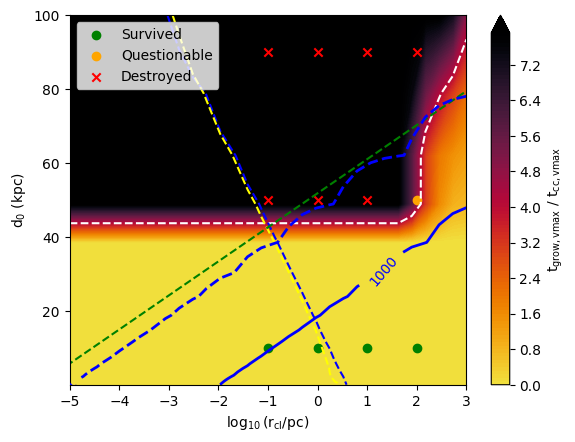

In [42]:
import cmasher as cmr
from matplotlib.colors import LogNorm
trat_arr10 = np.reshape(fclst10,(len(d0lst10),len(rcllst10))).copy().T
infall_arr10 = np.reshape(vlst10,(len(d0lst10),len(rcllst10))).copy().T 
tgrow_line_10 = np.reshape( tgrow_10,(len(d0lst10),len(rcllst10))).copy().T

# Infall line
v10 = 15 # km/s
tlim10 = tgrow_line_10 * u.Myr.to('s')  / (v10*1e3 / 1e-10) * 100
vmax = 8
z10 = np.clip(trat_arr10,-np.inf, vmax)

# Turbulent destruction line
tcool10 = get_t_cool_n(1e5, strat_n(d0lst10) *10) # (Nd,)                                  # km/s (or whatever you mean)
rcl_line10 = tcool10 * v10*1e3 / 10 /u.pc.to('m')

# Fragmentation line
rclmesh, dmesh = np.meshgrid(rcllst10, d0lst10)
frag_ratio = rclmesh * u.pc.to('m') / (get_t_cool_min(strat_n(dmesh)*100*mbar, 1e4, mbar,Tmin=1e4, Tmax=1e6) * get_c_s(1e4)/1e2)

#latexify(columns=1)
plt.figure()
# Mask non-positive values for log scale
cnt = plt.contourf(np.log10(rcllst10),d0lst10,z10, levels=100, extend='max', vmax = 8, cmap='cmr.ember_r')
plt.colorbar(cnt, label=r't$_{\rm grow,vmax}$ / t$_{\rm cc,vmax}$')

plt.contour(np.log10(rcllst10),d0lst10,z10,levels=[4],colors='white',linestyles='dashed')
plt.contour(np.log10(rcllst10),d0lst10,tlim10,levels=[1],colors='blue',linestyles='dashed')
plt.contour(np.log10(rcllst10),d0lst10,infall_arr10,levels=[10],colors='yellow',linestyles='dashed')
plt.plot(np.log10(rcl_line10), d0lst10, color='green', linestyle='dashed')
contour_lines = plt.contour(np.log10(rcllst10), d0lst10, frag_ratio, 
                            levels=[1, 1000], 
                            colors='blue', 
                            linewidths=2, 
                            linestyles=['--', '-'])
plt.clabel(contour_lines, inline=True, fontsize=10, fmt='%g')

#Simulation results
radius_sim = [0.1,0.1,0.1,\
                1,1,1,\
                10,10,10,\
                100,100,100,]
d0_sim = [10,50,90,\
            10,50,90,\
            10,50,90,\
            10,50,90,]

survived = [0,3,6,9]
question = [10]
destroyed = list(set(range(12)) - set(survived) - set(question))

plt.scatter(np.log10([radius_sim[i] for i in survived]),
            [d0_sim[i] for i in survived],
            marker='o', color='green', label='Survived')
plt.scatter(np.log10([radius_sim[i] for i in question]),
            [d0_sim[i] for i in question],
            marker='o', color='orange', label='Questionable')
plt.scatter(np.log10([radius_sim[i] for i in destroyed]),
            [d0_sim[i] for i in destroyed],
            marker='x', color='red', label='Destroyed')
plt.legend(loc='upper left')


plt.xlim(np.log10(rcllst10.min()), np.log10(rcllst10.max()))
plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"d$_0$ (kpc)")
#plt.savefig("turbulent_infalling_map_v10.png", dpi=300)

Mask frag_ratio any: True


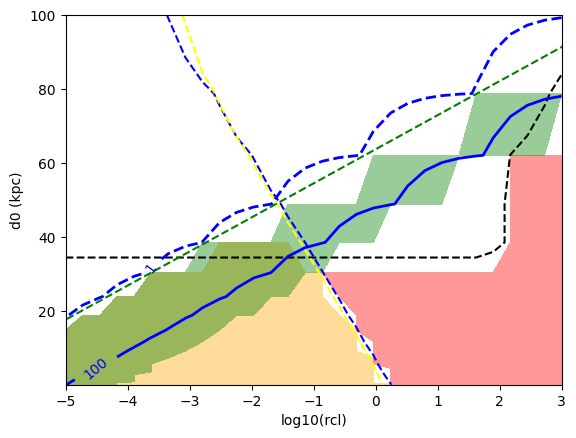

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.contour(np.log10(rcllst10),d0lst10,z10,levels=[4],colors='black',linestyles='dashed')
plt.contour(np.log10(rcllst10),d0lst10,tlim10,levels=[1],colors='blue',linestyles='dashed')
plt.contour(np.log10(rcllst10),d0lst10,infall_arr10,levels=[10],colors='yellow',linestyles='dashed')
plt.plot(np.log10(rcl_line10), d0lst10, color='green', linestyle='dashed')
mask_frag_ratio = (frag_ratio >= 1) & (frag_ratio <= 1000)
print("Mask frag_ratio any:", mask_frag_ratio.any())
contour_lines = plt.contour(np.log10(rcllst10), d0lst10, frag_ratio, 
                            levels=[1, 100], 
                            colors='blue', 
                            linewidths=2, 
                            linestyles=['--', '-'])
plt.clabel(contour_lines, inline=True, fontsize=10, fmt='%g')


#Fill between 
x_green = np.log10(rcl_line10)
X = np.log10(rcllst10)
mask_green = X > x_green[:, None]

mask_tlim = tlim10 <= 1

mask_between = mask_tlim & mask_green
mask_between = mask_between.astype(float)
mask_between[mask_between == 0] = np.nan

plt.contourf(
    np.log10(rcllst10),
    d0lst10,
    mask_between,
    levels=[0.5, 1.5],
    colors=['orange'],
    alpha=0.4
)

mask_blue = frag_ratio >= 100
mask_black = z10 <= 4
mask_above_infall = infall_arr10 >= 10
mask_infall = mask_blue & mask_black & mask_above_infall
mask_infall = mask_infall.astype(float)
mask_infall[mask_infall == 0] = np.nan
plt.contourf(
    np.log10(rcllst10),
    d0lst10,
    mask_infall,
    #levels=[0.5, 1.5],
    colors=['red'],
    alpha=0.4
)

#Fragmentation region
mask_frag = frag_ratio >= 1
mask_frag_upper = frag_ratio <= 1000
mask_a = mask_frag & mask_frag_upper
mask_a = mask_a.astype(float)
mask_a[mask_a == 0] = np.nan
plt.contourf(
    np.log10(rcllst10),
    d0lst10,
    mask_a,
    #levels=[0.5, 1.5],
    colors=['green'],
    alpha=0.4
)

plt.xlim(np.log10(rcllst10.min()), np.log10(rcllst10.max()))
plt.xlabel('log10(rcl)')
plt.ylabel('d0 (kpc)')
plt.show()

In [7]:
## For v=70
rcllst70 = np.logspace(-5,3,30)
d0lst70  = np.logspace(-1,2,30) #70,10)

combs = list(itertools.product(rcllst70,d0lst70))
vlst70 = []
fclst70 = []
tgrow_70 = []
for rcl, d0 in tqdm(combs):
    tt, tgrow = get_v_at_m3m0(rcl,d0, vturb=70)
    trat = get_tgrow_over_tcc_at_vmax(rcl, d0, vturb=70)
    vlst70.append(tt/1e3)
    fclst70.append(trat[0])
    tgrow_70.append(tgrow)

  0%|          | 0/900 [00:00<?, ?it/s]

This is Tcool0: 1.2025477349244795e-07
This is gtgrow0: 3.1419354803362294e-05
A termination event occurred.
This is Tcool0: 1.2025477349244795e-07
This is gtgrow0: 3.1419354803362294e-05
A termination event occurred.
This is Tcool0: 1.2106558150585252e-07
This is gtgrow0: 3.148171305577644e-05
A termination event occurred.
This is Tcool0: 1.2106558150585252e-07
This is gtgrow0: 3.148171305577644e-05
A termination event occurred.
This is Tcool0: 1.2210258861951093e-07
This is gtgrow0: 3.155484896147757e-05
A termination event occurred.
This is Tcool0: 1.2210258861951093e-07
This is gtgrow0: 3.155484896147757e-05
A termination event occurred.
This is Tcool0: 1.234315056884804e-07
This is gtgrow0: 3.164405642378829e-05
A termination event occurred.
This is Tcool0: 1.234315056884804e-07
This is gtgrow0: 3.164405642378829e-05
A termination event occurred.
This is Tcool0: 1.2513884993632264e-07
This is gtgrow0: 3.175522610829143e-05
A termination event occurred.
This is Tcool0: 1.2513884993

/tmp/ipykernel_2640885/3967006464.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \


A termination event occurred.
This is Tcool0: 1.3389478567190037e-07
This is gtgrow0: 3.229961749467413e-05
A termination event occurred.
This is Tcool0: 1.3389478567190037e-07
This is gtgrow0: 3.229961749467413e-05
A termination event occurred.
This is Tcool0: 1.387508010141542e-07
This is gtgrow0: 3.258892450598618e-05
A termination event occurred.
This is Tcool0: 1.387508010141542e-07
This is gtgrow0: 3.258892450598618e-05
A termination event occurred.
This is Tcool0: 1.4516730718203828e-07
This is gtgrow0: 3.295954983624393e-05
A termination event occurred.
This is Tcool0: 1.4516730718203828e-07
This is gtgrow0: 3.295954983624393e-05
A termination event occurred.
This is Tcool0: 1.5373858244339495e-07
This is gtgrow0: 3.343579033287874e-05
A termination event occurred.
This is Tcool0: 1.5373858244339495e-07
This is gtgrow0: 3.343579033287874e-05
A termination event occurred.
This is Tcool0: 1.6534761532712565e-07
This is gtgrow0: 3.4049950309889414e-05
A termination event occurred.

0.005877481107602604 587748.1107602604


Text(0, 0.5, 'd$_0$ (kpc)')

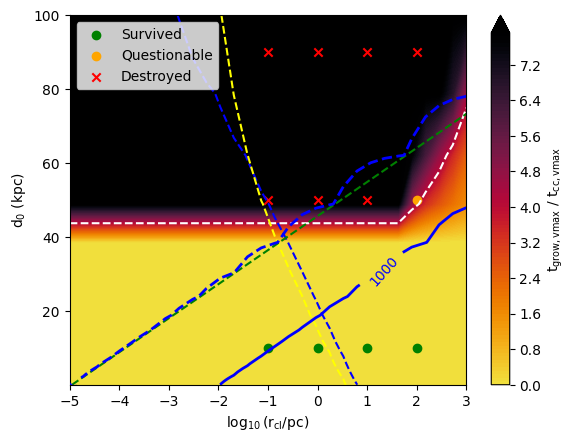

In [45]:
import cmasher as cmr
from matplotlib.colors import LogNorm
trat_arr70 = np.reshape(fclst70,(len(d0lst70),len(rcllst70))).copy().T
infall_arr70 = np.reshape(vlst70,(len(d0lst70),len(rcllst70))).copy().T 
tgrow_line_70 = np.reshape( tgrow_70,(len(d0lst70),len(rcllst70))).copy().T

# Infall line
v70 = 70 # km/s
tlim70 = tgrow_line_70 * u.Myr.to('s') / (v70*1e3 / 1e-10) * 100
vmax = 8
z70 = np.clip(trat_arr70,-np.inf, vmax)

# Turbulent destruction line
tcool70 = get_t_cool_n(1e5, strat_n(d0lst70) *10) # (Nd,)                                  # km/s (or whatever you mean)
rcl_line70 = tcool70 * v70*1e3 / 10 /u.pc.to('m')
# Fragmentation line
rclmesh, dmesh = np.meshgrid(rcllst70, d0lst70)
frag_ratio = rclmesh * u.pc.to('m') / (get_t_cool_min(strat_n(dmesh)*100*mbar, 1e4, mbar,Tmin=1e4, Tmax=1e6) * get_c_s(1e4)/1e2)
tlim702 =  rclmesh * u.pc.to('m') / v70 * 1e3 / (150*1e3 / 2/ 1e-10)
print(tlim702.min(), tlim702.max())

#latexify(columns=1)
plt.figure()
# Mask non-positive values for log scale
cnt = plt.contourf(np.log10(rcllst70),d0lst70,z70, levels=100, extend='max', vmax = 8, cmap='cmr.ember_r')
plt.colorbar(cnt, label=r't$_{\rm grow,vmax}$ / t$_{\rm cc,vmax}$')

plt.contour(np.log10(rcllst70),d0lst70,z70,levels=[4],colors='white',linestyles='dashed')
plt.contour(np.log10(rcllst70),d0lst70,tlim70,levels=[1],colors='blue',linestyles='dashed')
plt.contour(np.log10(rcllst70),d0lst70,infall_arr70,levels=[10],colors='yellow',linestyles='dashed')
plt.plot(np.log10(rcl_line70), d0lst70, color='green', linestyle='dashed')
contour_lines = plt.contour(np.log10(rcllst70), d0lst70, frag_ratio, 
                            levels=[1, 1000], 
                            colors='blue', 
                            linewidths=2, 
                            linestyles=['--', '-'])
plt.clabel(contour_lines, inline=True, fontsize=10, fmt='%g')

#Simulation results
radius_sim = [0.1,0.1,0.1,\
                1,1,1,\
                10,10,10,\
                100,100,100,]
d0_sim = [10,50,90,\
            10,50,90,\
            10,50,90,\
            10,50,90,]

survived = [0,3,6,9]
question = [10]
destroyed = list(set(range(12)) - set(survived) - set(question))

plt.scatter(np.log10([radius_sim[i] for i in survived]),
            [d0_sim[i] for i in survived],
            marker='o', color='green', label='Survived')
plt.scatter(np.log10([radius_sim[i] for i in question]),
            [d0_sim[i] for i in question],
            marker='o', color='orange', label='Questionable')
plt.scatter(np.log10([radius_sim[i] for i in destroyed]),
            [d0_sim[i] for i in destroyed],
            marker='x', color='red', label='Destroyed')
plt.legend(loc='upper left')


plt.xlim(np.log10(rcllst70.min()), np.log10(rcllst70.max()))
plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"d$_0$ (kpc)")
#plt.savefig("turbulent_infalling_map_v70.png", dpi=300)

In [43]:
rcllst70 = np.logspace(-1,2,30)
d0lst70  = np.logspace(-1,2,30)


## For v=70
rcllst70 = np.logspace(-1,2,30)
d0lst70  = np.logspace(-1,2,30) #70,10)

combs = list(itertools.product(rcllst70,d0lst70))
vlst70 = []
fclst70 = []
tgrow_70 = []
for rcl, d0 in tqdm(combs):
    tt, tgrow = get_v_at_m3m0(rcl,d0, vturb=70)
    trat = get_tgrow_over_tcc_at_vmax(rcl, d0, vturb=70)
    vlst70.append(tt/1e3)
    fclst70.append(trat[0])
    tgrow_70.append(tgrow)

  0%|          | 0/900 [00:00<?, ?it/s]

This is Tcool0: 1.2025477349244796e-06
This is gtgrow0: 0.05587239172352672
A termination event occurred.
This is Tcool0: 1.2025477349244796e-06
This is gtgrow0: 0.05587239172352672
A termination event occurred.
This is Tcool0: 1.210655815058525e-06
This is gtgrow0: 0.055983282119840785
A termination event occurred.
This is Tcool0: 1.210655815058525e-06
This is gtgrow0: 0.055983282119840785
A termination event occurred.
This is Tcool0: 1.2210258861951093e-06
This is gtgrow0: 0.05611333819508365
A termination event occurred.
This is Tcool0: 1.2210258861951093e-06
This is gtgrow0: 0.05611333819508365
A termination event occurred.
This is Tcool0: 1.2343150568848036e-06
This is gtgrow0: 0.05627197398853263
A termination event occurred.
This is Tcool0: 1.2343150568848036e-06
This is gtgrow0: 0.05627197398853263
A termination event occurred.
This is Tcool0: 1.2513884993632267e-06
This is gtgrow0: 0.05646966474950509
A termination event occurred.
This is Tcool0: 1.2513884993632267e-06
This is

/tmp/ipykernel_1990613/1113970134.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \


This is Tcool0: 1.387508010141542e-06
This is gtgrow0: 0.0579522134443081
A termination event occurred.
This is Tcool0: 1.387508010141542e-06
This is gtgrow0: 0.0579522134443081
A termination event occurred.
This is Tcool0: 1.4516730718203828e-06
This is gtgrow0: 0.05861128883794436
A termination event occurred.
This is Tcool0: 1.4516730718203828e-06
This is gtgrow0: 0.05861128883794436
A termination event occurred.
This is Tcool0: 1.5373858244339495e-06
This is gtgrow0: 0.05945817750733673
A termination event occurred.
This is Tcool0: 1.5373858244339495e-06
This is gtgrow0: 0.05945817750733673
A termination event occurred.
This is Tcool0: 1.6534761532712565e-06
This is gtgrow0: 0.06055032554892478
A termination event occurred.
This is Tcool0: 1.6534761532712565e-06
This is gtgrow0: 0.06055032554892478
A termination event occurred.
This is Tcool0: 1.8134947402130502e-06
This is gtgrow0: 0.06196504525741341
A termination event occurred.
This is Tcool0: 1.8134947402130502e-06
This is gtg

Text(0, 0.5, 'd$_0$ (kpc)')

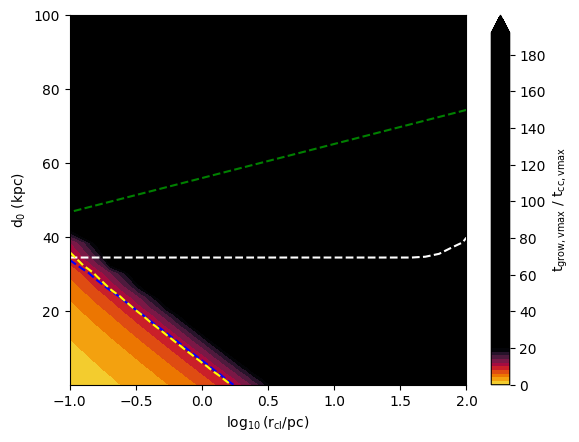

In [58]:
import cmasher as cmr
trat_arr70 = np.reshape(fclst70,(len(d0lst70),len(rcllst70))).copy().T
infall_arr70 = np.reshape(vlst70,(len(d0lst70),len(rcllst70))).copy().T 
tgrow_line_70 = np.reshape( tgrow_70,(len(d0lst70),len(rcllst70))).copy().T

# Infall line
v70 = 70
tlim = tgrow_line_70 * u.Myr.to('s') * (150/v70) **(3/5) / (15000/20/ 1e-10)
vmax = 8
z70 = np.clip(trat_arr70,-np.inf, vmax)

# Turbulent destruction line
tcool70 = get_t_cool_n(1e4, strat_n(d0lst70)) # (Nd,)                                  # km/s (or whatever you mean)
rcl_line70 = tcool70 * v70 / 10 /u.pc.to('m')
#latexify(columns=1)
plt.figure()
#cnt = plt.contourf(np.log10(rcllst70),d0lst70,z70, vmax=vmax, levels=100, extend='max', cmap='cmr.ember_r')
cnt = plt.contourf(np.log10(rcllst70),d0lst70,infall_arr70, levels=100, extend='max', vmax = 20, cmap='cmr.ember_r')
plt.colorbar(label=r't$_{\rm grow,vmax}$ / t$_{\rm cc,vmax}$')

plt.contour(np.log10(rcllst70),d0lst70,z70,levels=[4],colors='white',linestyles='dashed')
plt.contour(np.log10(rcllst70),d0lst70,tlim,levels=[1],colors='blue',linestyles='dashed')
plt.contour(np.log10(rcllst70),d0lst70,infall_arr70,levels=[10],colors='yellow',linestyles='dashed')
plt.plot(np.log10(rcl_line70), d0lst70, color='green', linestyle='dashed')
plt.xlim(np.log10(rcllst70.min()), np.log10(rcllst70.max()))
plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"d$_0$ (kpc)")